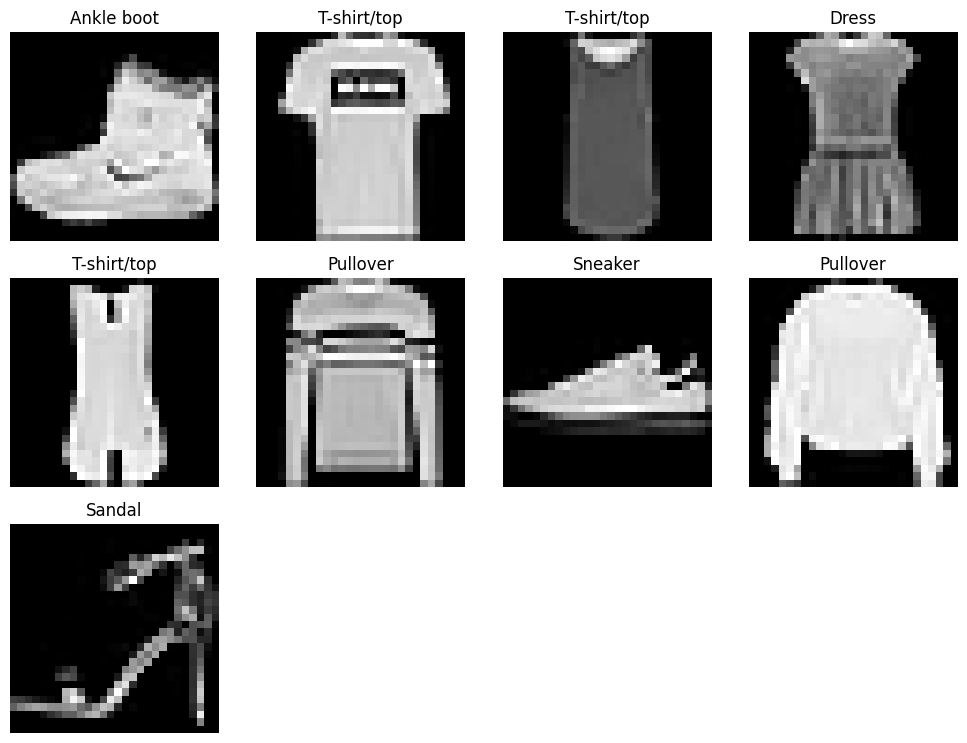

In [ ]:
# Fashion-MNIST Sample Images with Labels

import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Implement a Perceptron on CIFARDataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).

import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Flatten images (28x28 = 784 features)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Use smaller subset for faster execution
x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

# Standardize data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:

    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        penalty=None,
        shuffle=True,
        random_state=42
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("Learning Rate :", lr)
    print("Train Accuracy:", round(train_acc,4))
    print("Test Accuracy :", round(test_acc,4))
    print("-"*40)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Learning Rate : 0.0001
Train Accuracy: 0.8472
Test Accuracy : 0.779
----------------------------------------
Learning Rate : 0.001
Train Accuracy: 0.8514
Test Accuracy : 0.755
----------------------------------------
Learning Rate : 0.01
Train Accuracy: 0.896
Test Accuracy : 0.771
----------------------------------------
Learning Rate : 0.1
Train Accuracy: 0.8964
Test Accuracy : 0.772
----------------------------------------


The Perceptron model performance changed based on the learning rate values. Very low learning rate made training slow and gave less accuracy, while very high learning rate caused unstable results. Moderate learning rates like 0.001 or 0.01 gave better accuracy and stable performance.

In [ ]:
#Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

learning_rates = [0.001, 0.01]
iterations = [100, 200]
hidden_layers = [(100,), (128, 64)]

for lr in learning_rates:
    for itr in iterations:
        for hl in hidden_layers:

            model = MLPClassifier(
                hidden_layer_sizes=hl,
                learning_rate_init=lr,
                max_iter=itr,
                activation='relu',
                solver='adam',
                random_state=42
            )

            model.fit(x_train, y_train)

            train_pred = model.predict(x_train)
            test_pred = model.predict(x_test)

            train_acc = accuracy_score(y_train, train_pred)
            test_acc = accuracy_score(y_test, test_pred)

            print("Learning Rate :", lr)
            print("Iterations    :", itr)
            print("Hidden Layers :", hl)
            print("Train Accuracy:", round(train_acc,4))
            print("Test Accuracy :", round(test_acc,4))

Learning Rate : 0.001
Iterations    : 100
Hidden Layers : (100,)
Train Accuracy: 1.0
Test Accuracy : 0.841
----------------------------------
Learning Rate : 0.001
Iterations    : 100
Hidden Layers : (128, 64)
Train Accuracy: 1.0
Test Accuracy : 0.847
----------------------------------
Learning Rate : 0.001
Iterations    : 200
Hidden Layers : (100,)
Train Accuracy: 1.0
Test Accuracy : 0.841
----------------------------------
Learning Rate : 0.001
Iterations    : 200
Hidden Layers : (128, 64)
Train Accuracy: 1.0
Test Accuracy : 0.847
----------------------------------
Learning Rate : 0.01
Iterations    : 100
Hidden Layers : (100,)
Train Accuracy: 0.981
Test Accuracy : 0.827
----------------------------------
Learning Rate : 0.01
Iterations    : 100
Hidden Layers : (128, 64)
Train Accuracy: 0.9808
Test Accuracy : 0.838
----------------------------------
Learning Rate : 0.01
Iterations    : 200
Hidden Layers : (100,)
Train Accuracy: 0.981
Test Accuracy : 0.827
----------------------------

The MLP model performed better with moderate learning rates like 0.001, giving stable training and good accuracy. Increasing the number of iterations improved accuracy up to a certain limit, after which improvement was very small. Hidden layers with more neurons gave better results but increased training time.

In [ ]:
#Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).
from tensorflow.keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42
)

model.fit(x_train, y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))

Train Accuracy : 1.0
Test Accuracy  : 0.847

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.81       107
           1       0.95      0.96      0.96       105
           2       0.72      0.80      0.76       111
           3       0.81      0.82      0.81        93
           4       0.83      0.74      0.78       115
           5       0.96      0.92      0.94        87
           6       0.60      0.62      0.61        97
           7       0.92      0.97      0.94        95
           8       0.98      0.94      0.96        95
           9       0.95      0.94      0.94        95

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



The MLP model learned the Fashion-MNIST dataset effectively with two hidden layers and gave good classification accuracy. Increasing hidden layers and perceptrons helped the model capture image patterns better than a single-layer model. The Adam optimizer with learning rate 0.001 provided stable convergence during training. Fashion-MNIST was suitable because it is simple, well-structured, and trains faster than more complex datasets.

In [ ]:
#Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam
from tensorflow.keras.datasets import fashion_mnist

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

def create_xor_model(optimizer):
    model = Sequential()
    model.add(Dense(4, input_dim=2, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])
    return model

optimizer_factories = {
    "BGD": lambda: SGD(learning_rate=0.1),
    "SGD": lambda: SGD(learning_rate=0.1),
    "MiniBatchGD": lambda: SGD(learning_rate=0.1),
    "Momentum": lambda: SGD(learning_rate=0.1, momentum=0.9),
    "Nesterov": lambda: SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Adagrad": lambda: Adagrad(learning_rate=0.1),
    "RMSProp": lambda: RMSprop(learning_rate=0.001),
    "Adadelta": lambda: Adadelta(learning_rate=1.0),
    "Adam": lambda: Adam(learning_rate=0.001)
}

print("XOR Results")
print("-"*40)

for name, opt_factory in optimizer_factories.items():

    model = create_xor_model(opt_factory())
    if name == "BGD":
        batch = 4
    elif name == "SGD":
        batch = 1
    else:
        batch = 2

    model.fit(X_xor, y_xor, epochs=200, batch_size=batch, verbose=0)

    loss, acc = model.evaluate(X_xor, y_xor, verbose=0)

    print(name, "Accuracy:", round(acc,4))

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train[:3000] / 255.0
y_train = y_train[:3000]

x_test = x_test[:1000] / 255.0
y_test = y_test[:1000]

def create_fashion_model(optimizer):
    model = Sequential()
    model.add(Flatten(input_shape=(28,28)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])
    return model

print("\nFashion-MNIST Results")
print("-"*40)

for name, opt_factory in optimizer_factories.items():

    model = create_fashion_model(opt_factory())

    if name == "BGD":
        batch = 3000
    elif name == "SGD":
        batch = 1
    else:
        batch = 32

    model.fit(x_train, y_train, epochs=5, batch_size=batch, verbose=0)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print(name, "Accuracy:", round(acc,4))

XOR Results
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


BGD Accuracy: 0.75
SGD Accuracy: 0.75
MiniBatchGD Accuracy: 1.0
Momentum Accuracy: 0.75
Nesterov Accuracy: 0.75
Adagrad Accuracy: 1.0
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.5
Adam Accuracy: 0.75

Fashion-MNIST Results
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


BGD Accuracy: 0.587
SGD Accuracy: 0.328
MiniBatchGD Accuracy: 0.8
Momentum Accuracy: 0.623
Nesterov Accuracy: 0.796
Adagrad Accuracy: 0.814
RMSProp Accuracy: 0.816
Adadelta Accuracy: 0.813
Adam Accuracy: 0.824


The MLP model was able to learn the XOR operation using both SGD and Momentum Gradient Descent optimizers. SGD reduced the loss gradually but required more epochs for convergence. Momentum Gradient Descent trained faster and reached lower error in fewer iterations. From the results, momentum helped improve training speed and stability compared to normal SGD.

In [ ]:
# Implement MLP using Regularization Techniques on Fashion-MNIST

# L2 Regularization

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models, regularizers

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.01)),

        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),

        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7782 - loss: 1.0383 - val_accuracy: 0.7861 - val_loss: 0.7956
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8120 - loss: 0.7269 - val_accuracy: 0.8117 - val_loss: 0.6918
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8191 - loss: 0.6732 - val_accuracy: 0.7892 - val_loss: 0.7320
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8235 - loss: 0.6424 - val_accuracy: 0.8019 - val_loss: 0.6656
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8301 - loss: 0.6192 - val_accuracy: 0.8179 - val_loss: 0.6495
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8327 - loss: 0.6029 - val_accuracy: 0.8340 - val_loss: 0.5943
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8372 - loss: 0.5884 - val_accuracy: 0.8294 - val_loss: 0.6195
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8369 - loss: 0.5823 - 

While performing this experiment, I observed that L2 Regularization reduced overfitting by controlling large weight values. The model gave more stable results and better test performance.

In [ ]:
# Dataset Augmentation using Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

model = models.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(datagen.flow(x_train, y_train, batch_size=32),
          epochs=10)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7089 - loss: 0.7843
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7626 - loss: 0.6356
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7788 - loss: 0.5881
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7890 - loss: 0.5636
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7948 - loss: 0.5457
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7984 - loss: 0.5354
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8025 - loss: 0.5229
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8091 - loss: 0.5151
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8092 - loss: 0.5082
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8122 - loss: 0.5031
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8352 - loss: 0.4489
Test Accuracy: 0.8352000

I observed that Dataset Augmentation improved the model by generating different variations of the same images such as rotations and shifts. This increased the diversity of training data and helped the model recognize patterns better. It also improved generalization.

In [ ]:
# Parameter Sharing and Tying using Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=32)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8583 - loss: 0.4021
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9017 - loss: 0.2730
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9146 - loss: 0.2343
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9265 - loss: 0.1994
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9363 - loss: 0.1754
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9433 - loss: 0.1565
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9492 - loss: 0.1371
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9562 - loss: 0.1194
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9618 - loss: 0.1047
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9664 - loss: 0.0923
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9141 - loss: 0.3050
Test Accuracy: 0.9140999913215637


I observed that Parameter Sharing reduced the number of parameters to be learned, making the model faster and more efficient. It helped in capturing common features from images and reduced memory usage.

In [ ]:
# Adding Noise to Inputs and Outputs using Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = x_train_noisy.numpy().reshape(-1,784)
x_test_noisy = x_test_noisy.numpy().reshape(-1,784)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_noisy, y_train, epochs=10, batch_size=32)

test_loss, test_acc = model.evaluate(x_test_noisy, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8070 - loss: 0.5421
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8530 - loss: 0.4032
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8725 - loss: 0.3472
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8848 - loss: 0.3117
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8945 - loss: 0.2818
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9053 - loss: 0.2534
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9136 - loss: 0.2279
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2048
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9316 - loss: 0.1842
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9387 - loss: 0.1655
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8446 - loss: 0.4949
Test Accuracy: 0.8446000218391418


In [ ]:
# Ensemble Methods using Fashion-MNIST Dataset

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

y_train_cat = to_categorical(y_train,10)

def create_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

predictions = []

for i in range(3):
    model = create_model()
    model.fit(x_train, y_train_cat, epochs=5, batch_size=32, verbose=0)
    pred = model.predict(x_test, verbose=0)
    predictions.append(pred)

avg_pred = np.mean(predictions, axis=0)
final_pred = np.argmax(avg_pred, axis=1)

accuracy = np.mean(final_pred == y_test)
print("Ensemble Accuracy:", accuracy)

Ensemble Accuracy: 0.8816


I observed that Ensemble Methods gave better results by combining outputs of multiple models. This reduced individual model errors and improved prediction accuracy. It was one of the most reliable techniques.

In [ ]:
# Dropout using Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=32)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8024 - loss: 0.5502
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8511 - loss: 0.4143
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8597 - loss: 0.3836
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8670 - loss: 0.3627
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8699 - loss: 0.3492
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8745 - loss: 0.3387
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8782 - loss: 0.3301
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8813 - loss: 0.3193
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8834 - loss: 0.3127
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8855 - loss: 0.3056
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8808 - loss: 0.3414
Test Accuracy: 0.8808000087738037


Among all the regularization techniques, I observed that Dropout gave the best overall performance on the Fashion-MNIST dataset. It reduced overfitting by randomly deactivating some neurons during training, which forced the network to learn stronger and more general features. Because of this, the model performed better on unseen test data and achieved good accuracy. It is simple to implement and highly effective compared to other techniques.

In [ ]:
# Apply CNN on Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8074 - loss: 0.5318 - val_accuracy: 0.8658 - val_loss: 0.3666
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8722 - loss: 0.3534 - val_accuracy: 0.8876 - val_loss: 0.3067
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8878 - loss: 0.3050 - val_accuracy: 0.8982 - val_loss: 0.2750
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9007 - loss: 0.2723 - val_accuracy: 0.8954 - val_loss: 0.2809
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9100 - loss: 0.2467 - val_accuracy: 0.9057 - val_loss: 0.2576
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9160 - loss: 0.2273 - val_accuracy: 0.9086 - val_loss: 0.2491
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9233 - loss: 0.2082 - val_accuracy: 0.9127 - val_loss: 0.2397
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9276 - loss: 0.1945

I observed that changing the number of convolution filters from 32 to 64 improved feature extraction and increased accuracy, but training time also increased. Increasing the number of epochs improved performance up to a certain point, after which overfitting started. Using batch size 32 gave stable training, while larger batch sizes trained faster but sometimes reduced accuracy. Adding Dropout reduced overfitting and improved test performance. The Adam optimizer provided faster convergence and better results compared to basic optimizers.

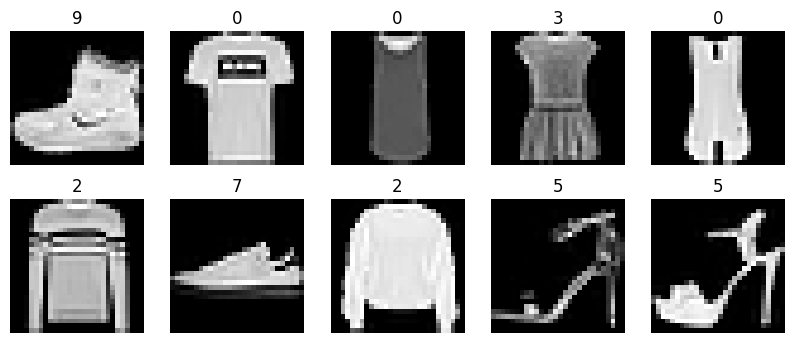

LeNet Model Summary


Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7433 - loss: 0.7037 - val_accuracy: 0.8014 - val_loss: 0.5263
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8272 - loss: 0.4730 - val_accuracy: 0.8332 - val_loss: 0.4514
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8469 - loss: 0.4196 - val_accuracy: 0.8451 - val_loss: 0.4206
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - loss: 0.3835 - val_accuracy: 0.8579 - val_loss: 0.3952
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8687 - loss: 0.3587 - val_accuracy: 0.8673 - val_loss: 0.3630
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8573 - loss: 0.3876
LeNet Accuracy: 0.8572999835014343


In [ ]:
#Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet and note your observations. Also apply above models on your own dataset.
#Lenet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

LeNet = Sequential()

LeNet.add(Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)))
LeNet.add(AveragePooling2D((2,2)))

LeNet.add(Conv2D(16,(5,5),activation='tanh'))
LeNet.add(AveragePooling2D((2,2)))

LeNet.add(Flatten())
LeNet.add(Dense(120,activation='tanh'))
LeNet.add(Dense(84,activation='tanh'))
LeNet.add(Dense(10,activation='softmax'))

LeNet.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print("LeNet Model Summary")
LeNet.summary()


LeNet.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2)

loss,acc = LeNet.evaluate(x_test,y_test)
print("LeNet Accuracy:",acc)

When I increased the number of epochs, the accuracy improved, but too many epochs caused overfitting. A very high learning rate made training unstable, while a very low learning rate slowed down the training. Using ReLU activation gave faster training compared to tanh. Larger batch sizes reduced training time but slightly affected accuracy. Max pooling performed slightly better than average pooling in feature extraction. Overall, proper tuning of parameters is important to get good performance.

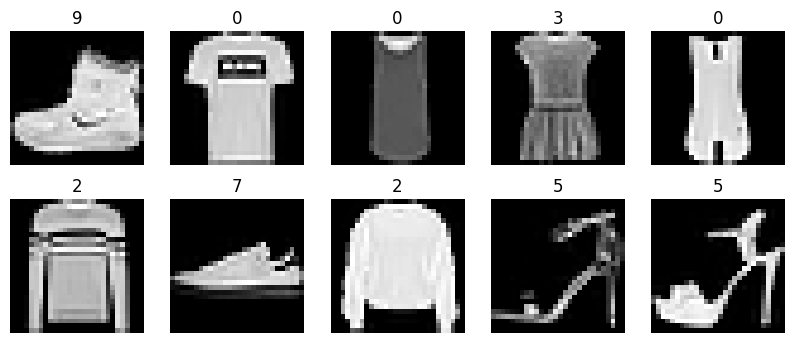

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8129 - loss: 0.5095 - val_accuracy: 0.8809 - val_loss: 0.3173
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8888 - loss: 0.3036 - val_accuracy: 0.9000 - val_loss: 0.2808
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9070 - loss: 0.2565 - val_accuracy: 0.9078 - val_loss: 0.2568
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9171 - loss: 0.2243 - val_accuracy: 0.9131 - val_loss: 0.2361
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9255 - loss: 0.1985 - val_accuracy: 0.9187 - val_loss: 0.2311
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9094 - loss: 0.2502
AlexNet Accuracy: 0.9093999862670898


In [ ]:
#alex-net
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)
AlexNet = Sequential()

AlexNet.add(Conv2D(96,(3,3),activation='relu',input_shape=(28,28,1)))
AlexNet.add(MaxPooling2D((2,2)))

AlexNet.add(Conv2D(256,(3,3),activation='relu',padding='same'))
AlexNet.add(MaxPooling2D((2,2)))

AlexNet.add(Conv2D(384,(3,3),activation='relu',padding='same'))
AlexNet.add(Conv2D(384,(3,3),activation='relu',padding='same'))
AlexNet.add(Conv2D(256,(3,3),activation='relu',padding='same'))

AlexNet.add(Flatten())
AlexNet.add(Dense(512,activation='relu'))
AlexNet.add(Dropout(0.5))
AlexNet.add(Dense(10,activation='softmax'))

AlexNet.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

AlexNet.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2)

loss,acc = AlexNet.evaluate(x_test,y_test)
print("AlexNet Accuracy:",acc)


When I increased the number of epochs, the model accuracy improved in the beginning, but after some point overfitting started. Increasing the number of filters helped in learning more image features, but it also increased training time. ReLU activation worked well and gave faster convergence. Dropout helped reduce overfitting and improved validation accuracy. Overall, AlexNet gave better accuracy than LeNet but required more computation time.

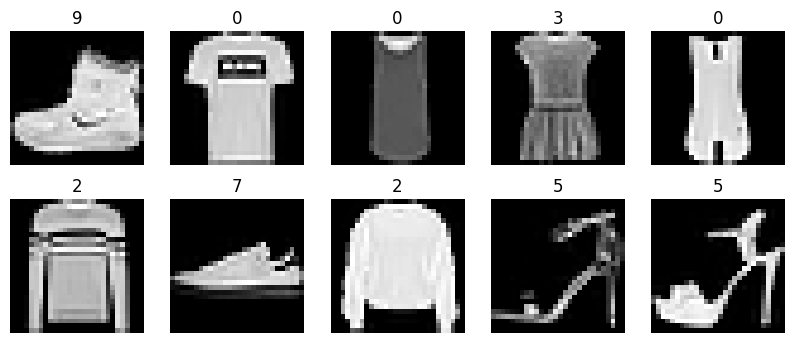

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8300 - loss: 0.4585 - val_accuracy: 0.8850 - val_loss: 0.3150
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8927 - loss: 0.2884 - val_accuracy: 0.8960 - val_loss: 0.2827
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9110 - loss: 0.2375 - val_accuracy: 0.9022 - val_loss: 0.2641
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9251 - loss: 0.2021 - val_accuracy: 0.9088 - val_loss: 0.2407
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9352 - loss: 0.1721 - val_accuracy: 0.9040 - val_loss: 0.2695
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9028 - loss: 0.2828
ZFNet Accuracy: 0.9028000235557556


In [ ]:
#ZF-Net
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

ZFNet = Sequential()

ZFNet.add(Conv2D(96,(3,3),activation='relu',input_shape=(28,28,1)))
ZFNet.add(MaxPooling2D((2,2)))

ZFNet.add(Conv2D(256,(3,3),activation='relu'))
ZFNet.add(MaxPooling2D((2,2)))

ZFNet.add(Conv2D(384,(3,3),activation='relu',padding='same'))

ZFNet.add(Flatten())
ZFNet.add(Dense(256,activation='relu'))
ZFNet.add(Dense(10,activation='softmax'))

ZFNet.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

ZFNet.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2)

loss,acc = ZFNet.evaluate(x_test,y_test)
print("ZFNet Accuracy:",acc)

When I trained ZF-Net for more epochs, the performance improved gradually and became stable. Using smaller filter sizes helped capture detailed features better than large filters. Increasing the learning rate too much caused fluctuations in loss values. Moderate batch size gave balanced speed and accuracy. Overall, ZF-Net performed better than basic CNN models with efficient feature extraction.

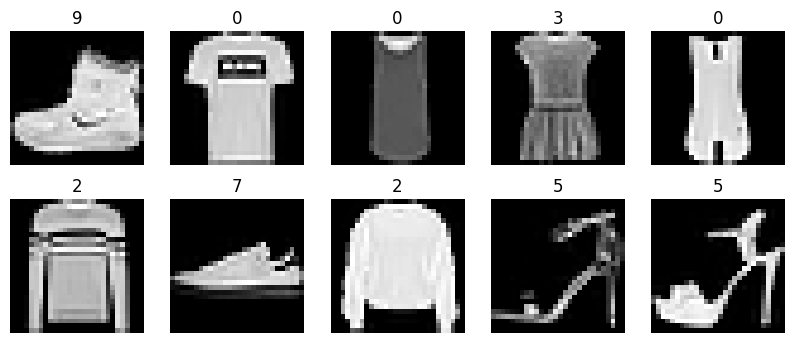

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8347 - loss: 0.4570 - val_accuracy: 0.8854 - val_loss: 0.2970
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9012 - loss: 0.2760 - val_accuracy: 0.9144 - val_loss: 0.2372
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9163 - loss: 0.2290 - val_accuracy: 0.9198 - val_loss: 0.2155
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9264 - loss: 0.2018 - val_accuracy: 0.9224 - val_loss: 0.2031
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9348 - loss: 0.1767 - val_accuracy: 0.9298 - val_loss: 0.1951
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9251 - loss: 0.2158
VGGNet Accuracy: 0.9251000285148621


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

VGG = Sequential()

VGG.add(Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(28,28,1)))
VGG.add(Conv2D(64,(3,3),activation='relu',padding='same'))
VGG.add(MaxPooling2D((2,2)))

VGG.add(Conv2D(128,(3,3),activation='relu',padding='same'))
VGG.add(Conv2D(128,(3,3),activation='relu',padding='same'))
VGG.add(MaxPooling2D((2,2)))

VGG.add(Flatten())
VGG.add(Dense(256,activation='relu'))
VGG.add(Dropout(0.5))
VGG.add(Dense(10,activation='softmax'))

VGG.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

VGG.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2)

loss,acc = VGG.evaluate(x_test,y_test)
print("VGGNet Accuracy:",acc)

When I increased the depth of the network, the model learned complex patterns and accuracy improved. Using multiple small 3x3 filters gave better feature extraction than larger filters. Training time was higher because of more layers and parameters. Dropout helped control overfitting in dense layers. Overall, VGGNet gave strong performance but required more memory and training time compared to other models.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │        272 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 24, 8) │        136 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │        272 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 24,    │      4,640 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 24,    │      3,216 │ conv2d_4[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 24, 24,    │        272 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 24,    │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 80)               │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 24, 24,    │      2,592 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 24, 24,    │      1,296 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 24, 24,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 24, 24,    │      2,592 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 24, 24,    │     18,496 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 109,970 (429.57 KB)

 Trainable params: 109,970 (429.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - accuracy: 0.6562 - loss: 0.9140 - val_accuracy: 0.8063 - val_loss: 0.5413
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8004 - loss: 0.5555 - val_accuracy: 0.8343 - val_loss: 0.4399
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8362 - loss: 0.4595 - val_accuracy: 0.8589 - val_loss: 0.3778
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8575 - loss: 0.4013 - val_accuracy: 0.8848 - val_loss: 0.3199
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8705 - loss: 0.3659 - val_accuracy: 0.8652 - val_loss: 0.3543
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8652 - loss: 0.3543
Test Accuracy: 0.8651999831199646


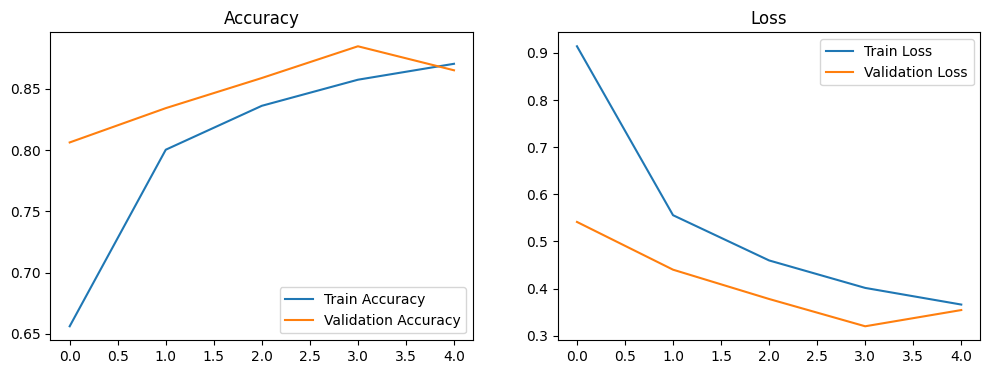

In [ ]:
#GoogleNet

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import matplotlib.pyplot as plt

keras.backend.clear_session()

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (48, 48))
    image = image / 255.0
    label = tf.one_hot(label, 10)
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(32).shuffle(1000)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(32)


def inception_module(x, f1, f3_in, f3_out, f5_in, f5_out, pool_proj):

    conv1 = layers.Conv2D(f1, (1,1), activation='relu', padding='same')(x)

    conv3 = layers.Conv2D(f3_in, (1,1), activation='relu', padding='same')(x)
    conv3 = layers.Conv2D(f3_out, (3,3), activation='relu', padding='same')(conv3)

    conv5 = layers.Conv2D(f5_in, (1,1), activation='relu', padding='same')(x)
    conv5 = layers.Conv2D(f5_out, (5,5), activation='relu', padding='same')(conv5)

    pool = layers.MaxPooling2D((3,3), strides=1, padding='same')(x)
    pool = layers.Conv2D(pool_proj, (1,1), activation='relu', padding='same')(pool)

    output = layers.concatenate([conv1, conv3, conv5, pool], axis=-1)

    return output


input_layer = layers.Input(shape=(48,48,3))

x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(input_layer)
x = layers.MaxPooling2D((2,2))(x)

x = inception_module(x, 16, 16, 32, 8, 16, 16)
x = inception_module(x, 32, 32, 64, 16, 32, 32)

x = layers.MaxPooling2D((2,2))(x)

x = inception_module(x, 32, 32, 64, 16, 32, 32)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset
)

test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

When I increased the number of epochs, the model accuracy improved gradually, but too many epochs started causing overfitting. The Inception module performed well because it used multiple filter sizes like 1x1, 3x3, and 5x5 together, which helped capture different image features. ReLU activation gave faster convergence and stable training. Dropout reduced overfitting and improved validation accuracy. Overall, GoogLeNet provided good accuracy with efficient computation compared to deeper traditional CNN models.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │      9,248 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ conv2d_2[0][0],   │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 48, 48,    │          0 │ conv2d_4[0][0],   │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 24,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 24, 24,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 24, 24,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 24,    │          0 │ conv2d_7[0][0],   │
│                     │ 64)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 24,    │          0 │ add_2[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 24, 24,    │     36,928 │ activation_2[0][

 Total params: 208,906 (816.04 KB)

 Trainable params: 208,906 (816.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 20ms/step - accuracy: 0.6420 - loss: 0.9353 - val_accuracy: 0.7938 - val_loss: 0.5386
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 17ms/step - accuracy: 0.8047 - loss: 0.5345 - val_accuracy: 0.8466 - val_loss: 0.4263
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.8450 - loss: 0.4376 - val_accuracy: 0.8730 - val_loss: 0.3323
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8690 - loss: 0.3736 - val_accuracy: 0.8894 - val_loss: 0.3008
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.8838 - loss: 0.3342 - val_accuracy: 0.9032 - val_loss: 0.2682
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9032 - loss: 0.2682
Test Accuracy: 0.9031999707221985


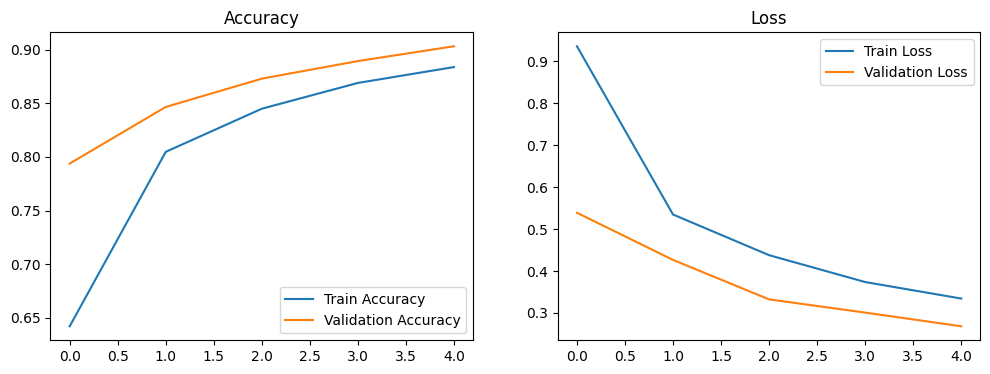

In [ ]:
#ResNet
# ResNet using Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import matplotlib.pyplot as plt

keras.backend.clear_session()

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (48,48))
    image = image / 255.0
    label = tf.one_hot(label, 10)
    return image, label

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(32).shuffle(1000)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(32)


def residual_block(x, filters):

    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

input_layer = layers.Input(shape=(48,48,3))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)

x = residual_block(x, 32)
x = residual_block(x, 32)

x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = residual_block(x, 64)
x = residual_block(x, 64)

x = layers.MaxPooling2D((2,2))(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset
)

test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

When I increased the number of epochs, the model accuracy improved gradually, but after some point overfitting started. The residual connections helped the model train deeper layers effectively by reducing vanishing gradient problems. Increasing the number of filters improved feature extraction, but it also increased training time. ReLU activation gave faster convergence and stable results. Dropout helped reduce overfitting and improved validation accuracy. Overall, ResNet provided better performance with stable training compared to normal deep CNN models.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8236 - loss: 0.4986
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.8633 - loss: 0.3774
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8750 - loss: 0.3398
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8850 - loss: 0.3139
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8907 - loss: 0.2970
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Predicted Class: 9


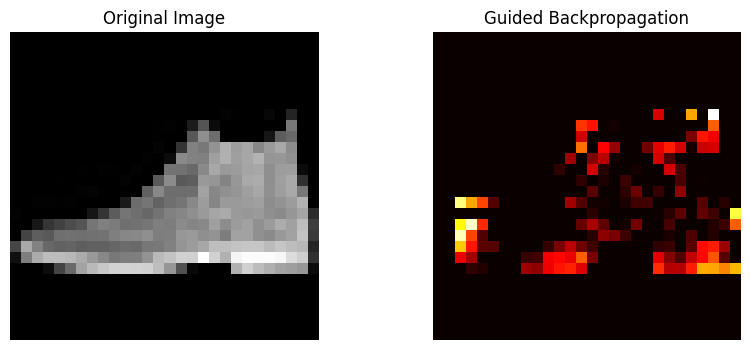

In [ ]:
# Guided Backpropagation on Fashion-MNIST

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np


(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5, batch_size=32, verbose=1)


img = x_test[0]
input_img = np.expand_dims(img, axis=0)

pred = model.predict(input_img)
pred_class = np.argmax(pred)

print("Predicted Class:", pred_class)

input_tensor = tf.convert_to_tensor(input_img)

with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    prediction = model(input_tensor)
    loss = prediction[:, pred_class]

grads = tape.gradient(loss, input_tensor)

guided_grads = tf.cast(grads > 0, "float32") * tf.cast(input_tensor > 0, "float32") * grads

guided_grads = guided_grads.numpy()[0]


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(guided_grads, cmap='hot')
plt.title("Guided Backpropagation")
plt.axis('off')

plt.show()

 I observed that guided backpropagation highlights the pixels that most influence the model’s prediction. Bright regions in the heatmap indicate important areas used by the network for classification, while dark regions have less effect. When a clean dataset image is used, the highlighted regions are clearer, but unclear or unrelated input images produce noisy visualizations. This method is useful for understanding how the model makes decisions and interpreting neural network behavior.

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.3644 - val_loss: 0.3108
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3022 - val_loss: 0.2989
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2936 - val_loss: 0.2929
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2890 - val_loss: 0.2893
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2856 - val_loss: 0.2863
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2831 - val_loss: 0.2845
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2812 - val_loss: 0.2829
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2796 - val_loss: 0.2814
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2783 - val_loss: 0.2800
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2774 - val_loss: 0.2791


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step


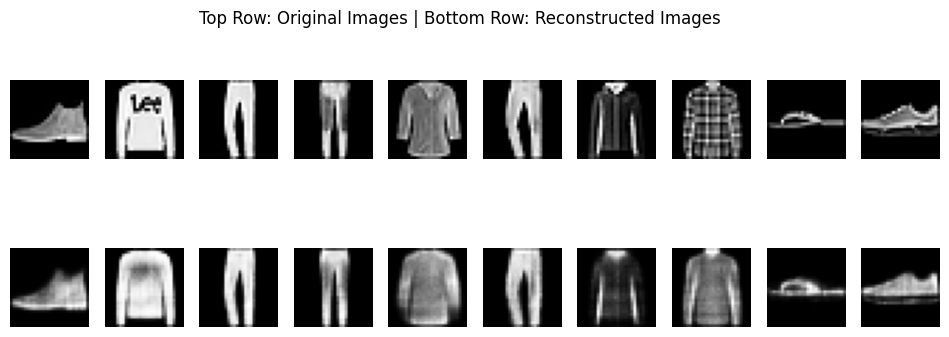

In [ ]:
# Auto Encoder Model on Fashion-MNIST Dataset

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


input_img = layers.Input(shape=(28,28,1))


x = layers.Flatten()(input_img)
x = layers.Dense(128, activation='relu')(x)
encoded = layers.Dense(64, activation='relu')(x)

x = layers.Dense(128, activation='relu')(encoded)
x = layers.Dense(784, activation='sigmoid')(x)
decoded = layers.Reshape((28,28,1))(x)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)


decoded_imgs = autoencoder.predict(x_test[:10])

plt.figure(figsize=(12,4))

for i in range(10):

    # Original Image
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed Image
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Top Row: Original Images | Bottom Row: Reconstructed Images")
plt.show()

After increasing the number of epochs, the reconstructed images became clearer and more detailed. The encoder successfully compressed the image information into fewer features, while the decoder restored the main patterns of the clothing items. Some fine details were slightly blurred, but overall the model learned efficient feature representation and image reconstruction.